# IMPORT & LIBRARY

Pada tahap ini dilakukan import library yang digunakan dalam penelitian, meliputi pustaka untuk pemodelan time series (SARIMA), neural network (MLPRegressor), preprocessing data (MinMaxScaler), evaluasi model (MAE, MSE, RMSE, R²), serta visualisasi data.





In [ ]:
# ===============================
# Library utama
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualisasi
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# Statistik time series
# ===============================
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===============================
# Machine Learning (AMBP)
# ===============================
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ===============================
# Setting tampilan
# ===============================
plt.style.use('default')
sns.set_theme()

# DATA

Data curah hujan dibagi menjadi data training dan data aktual (testing). Setiap blok menggunakan skema rolling window selama 10 tahun untuk training dan 1 tahun berikutnya untuk pengujian, sehingga model dapat dievaluasi secara bertahap.

In [ ]:
# ===============================
# Load dataset
# ===============================
df = pd.read_excel("CHNTBFIX.xlsx")

# Hapus kolom Unnamed
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.tail()

,DATE,RAINFALL_MM
535,2025-08-01,11.26
536,2025-09-01,52.30
537,2025-10-01,76.20
538,2025-11-01,199.84
539,2025-12-01,246.83


In [ ]:
# Ubah kolom DATE menjadi datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Urutkan berdasarkan tanggal
df = df.sort_values('DATE')

# Set DATE sebagai index
rain_series = df.set_index('DATE')['RAINFALL_MM']

# Paksa frekuensi bulanan awal bulan
rain_series = rain_series.asfreq('MS')

rain_series.head()

,RAINFALL_MM
DATE,
1981-01-01,370.93
1981-02-01,326.56
1981-03-01,219.61
1981-04-01,116.93
1981-05-01,127.20


In [ ]:
print("Shape data:", rain_series.shape)
print("Tipe index:", type(rain_series.index))
print("Frekuensi:", rain_series.index.freq)
print("Periode data:",
      rain_series.index.min(),
      "sampai",
      rain_series.index.max())

Shape data: (540,)
Tipe index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Frekuensi: <MonthBegin>
Periode data: 1981-01-01 00:00:00 sampai 2025-12-01 00:00:00


In [ ]:
print("Jumlah missing value:", rain_series.isna().sum())
print("Jumlah nilai negatif:", (rain_series < 0).sum())
rain_series.describe()

Jumlah missing value: 0
Jumlah nilai negatif: 0


,RAINFALL_MM
count,540.000000
mean,108.293778
std,107.291980
min,0.180000
25%,9.387500
50%,80.570000
75%,181.645000
max,428.500000


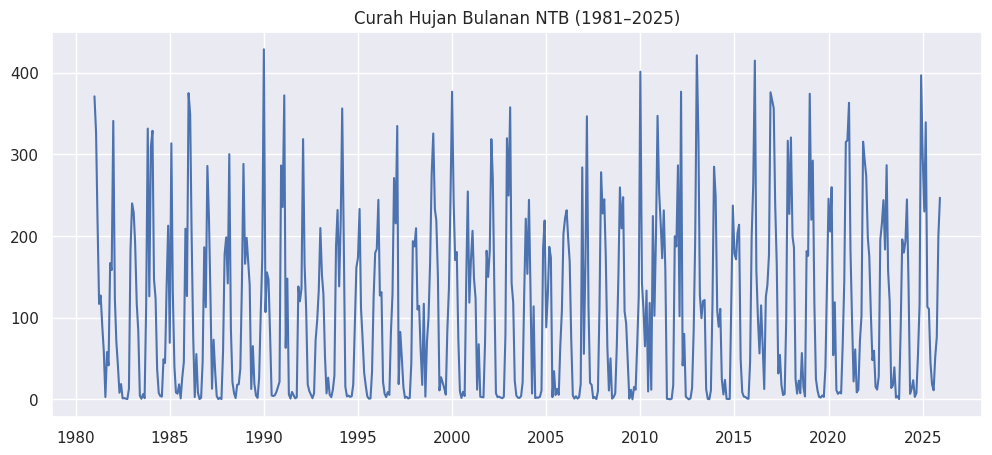

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(rain_series)
plt.title("Curah Hujan Bulanan NTB (1981–2025)")
plt.show()

# UJI ADF

Uji Augmented Dickey-Fuller (ADF) digunakan untuk menguji stasioneritas data time series. Hasil uji menunjukkan bahwa keputusan dilakukan berdasarkan nilai p-value dengan ambang batas 0.05. Jika data tidak stasioner, maka dilakukan differencing untuk memenuhi asumsi model SARIMA. Dalam penelitian ini digunakan differencing musiman (D=1) untuk menangkap pola tahunan pada data curah hujan.

In [ ]:
from statsmodels.tsa.stattools import adfuller

print("=== ADF TEST DATA ASLI ===")
result = adfuller(rain_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data STASIONER")
else:
    print("Data TIDAK STASIONER → perlu differencing")

=== ADF TEST DATA ASLI ===
ADF Statistic: -5.671213078228454
p-value: 8.913329967612267e-07
Data STASIONER


# Seasonal Differencing
Melakukan differencing musiman (lag 12) untuk menghilangkan pola tahunan, kemudian diuji dengan ADF untuk memastikan data sudah stasioner sebelum digunakan pada model SARIMA.

In [ ]:
rain_seasonal_diff = rain_series.diff(12).dropna()

print("\n=== ADF TEST SETELAH SEASONAL DIFFERENCING ===")
result2 = adfuller(rain_seasonal_diff)

print("ADF Statistic:", result2[0])
print("p-value:", result2[1])


=== ADF TEST SETELAH SEASONAL DIFFERENCING ===
ADF Statistic: -9.706533789177904
p-value: 1.0383068393511911e-16


# Identifikasi Parameter Model SARIMA (ACF dan PACF)

Pada tahap ini dilakukan analisis ACF (Autocorrelation Function) dan PACF (Partial Autocorrelation Function) terhadap data yang telah melalui seasonal differencing. Grafik ACF digunakan untuk mengidentifikasi komponen Moving Average (MA), sedangkan PACF digunakan untuk mengidentifikasi komponen Autoregressive (AR). Hasil analisis ini menjadi dasar dalam menentukan parameter model SARIMA yang optimal.

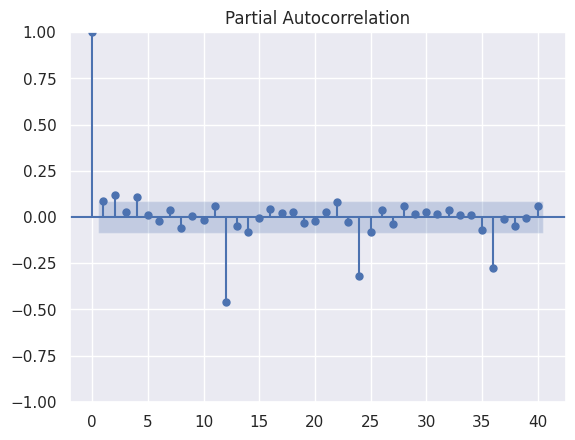

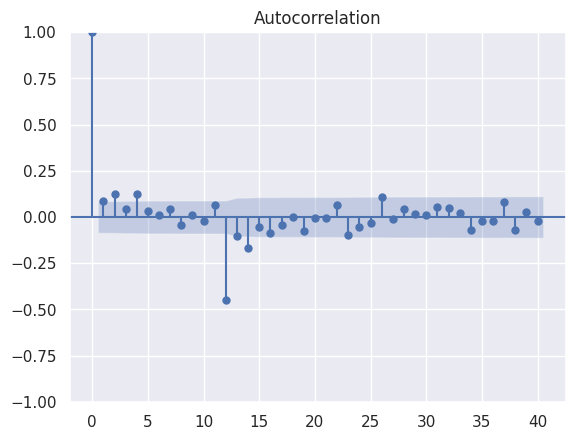

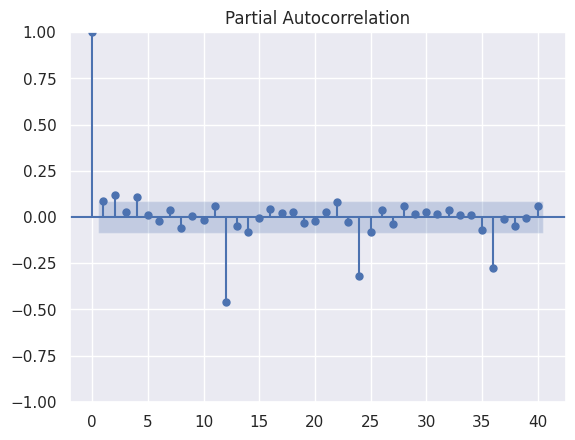

In [ ]:
plot_acf(rain_seasonal_diff, lags=40)
plot_pacf(rain_seasonal_diff, lags=40)

# Pemilihan Model SARIMA Terbaik (Model Selection)
Pada tahap ini dilakukan evaluasi beberapa kandidat model SARIMA menggunakan data training dan testing. Data dibagi menjadi 80% training dan 20% testing. Setiap model dilatih, kemudian digunakan untuk memprediksi data testing.

Kinerja model dievaluasi menggunakan:

*   AIC dan BIC → untuk mengukur kompleksitas dan kecocokan model
*   RMSE dan MAE → untuk mengukur akurasi prediksi
*   Ljung-Box test → untuk memastikan residual tidak mengandung autokorelasi (model sudah baik)

Seluruh hasil disimpan dan diurutkan berdasarkan nilai AIC terendah untuk menentukan model terbaik.

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

# ===============================
# SPLIT DATA
# ===============================
train_size = int(len(rain_series) * 0.8)
train = rain_series[:train_size]
test = rain_series[train_size:]

# ===============================
# KANDIDAT MODEL (FIX)
# ===============================
candidate_models = [
    ((0,0,1),(0,1,1,12)),
    ((1,0,1),(0,1,1,12)),
    ((2,0,1),(0,1,1,12)),
    ((1,0,2),(0,1,1,12)),
    ((2,0,2),(0,1,1,12)),

    ((0,0,1),(1,1,1,12)),
    ((1,0,1),(1,1,1,12)),
    ((2,0,1),(1,1,1,12)),

    ((1,1,1),(0,1,1,12)),
    ((2,1,1),(0,1,1,12)),
]

results = []

# ===============================
# LOOP EVALUASI
# ===============================
for order, seasonal_order in candidate_models:
    try:
        model = SARIMAX(train,
                        order=order,
                        seasonal_order=seasonal_order,
                        exog=None,
                        enforce_stationarity=False,
                        enforce_invertibility=False)

        fitted = model.fit(disp=False, maxiter=500)

        # Forecast
        forecast = fitted.forecast(steps=len(test))

        # Error metrics
        rmse = np.sqrt(np.mean((test - forecast)**2))
        mae = np.mean(np.abs(test - forecast))

        # Ljung-Box test
        lb_test = acorr_ljungbox(fitted.resid, lags=[12], return_df=True)
        lb_pvalue = lb_test['lb_pvalue'].values[0]

        results.append({
            'order': order,
            'seasonal_order': seasonal_order,
            'AIC': fitted.aic,
            'BIC': fitted.bic,
            'RMSE': rmse,
            'MAE': mae,
            'LjungBox_pvalue': lb_pvalue
        })

    except Exception as e:
        print(f"Model {order} {seasonal_order} gagal:", e)

# ===============================
# HASIL
# ===============================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='AIC')

print(results_df)

       order seasonal_order          AIC          BIC       RMSE        MAE  \
3  (1, 0, 2)  (0, 1, 1, 12)  4487.947149  4507.966585  59.164660  41.117297   
4  (2, 0, 2)  (0, 1, 1, 12)  4490.422115  4514.445438  59.400409  41.171473   
1  (1, 0, 1)  (0, 1, 1, 12)  4495.881276  4511.906688  60.260467  41.730429   
0  (0, 0, 1)  (0, 1, 1, 12)  4496.326712  4508.345771  60.270546  41.700232   
8  (1, 1, 1)  (0, 1, 1, 12)  4496.717468  4512.733016  57.124640  43.971914   
6  (1, 0, 1)  (1, 1, 1, 12)  4497.630691  4517.662457  60.322031  41.775180   
5  (0, 0, 1)  (1, 1, 1, 12)  4498.211835  4514.237248  60.292967  41.726548   
9  (2, 1, 1)  (0, 1, 1, 12)  4498.489615  4518.509050  57.065623  43.339791   
2  (2, 0, 1)  (0, 1, 1, 12)  4501.048702  4521.080468  59.376491  41.215709   
7  (2, 0, 1)  (1, 1, 1, 12)  4502.851502  4526.889621  59.381502  41.231177   

   LjungBox_pvalue  
3     3.894967e-01  
4     1.440897e-01  
1     1.329453e-12  
0     2.834853e-05  
8     2.915619e-01  
6   

In [ ]:
valid_models = results_df[results_df['LjungBox_pvalue'] > 0.05]
valid_models = valid_models.sort_values(by='AIC')

print("\n=== MODEL VALID ===")
print(valid_models)


=== MODEL VALID ===
       order seasonal_order          AIC          BIC       RMSE        MAE  \
3  (1, 0, 2)  (0, 1, 1, 12)  4487.947149  4507.966585  59.164660  41.117297   
4  (2, 0, 2)  (0, 1, 1, 12)  4490.422115  4514.445438  59.400409  41.171473   
8  (1, 1, 1)  (0, 1, 1, 12)  4496.717468  4512.733016  57.124640  43.971914   
9  (2, 1, 1)  (0, 1, 1, 12)  4498.489615  4518.509050  57.065623  43.339791   
2  (2, 0, 1)  (0, 1, 1, 12)  4501.048702  4521.080468  59.376491  41.215709   
7  (2, 0, 1)  (1, 1, 1, 12)  4502.851502  4526.889621  59.381502  41.231177   

   LjungBox_pvalue  
3         0.389497  
4         0.144090  
8         0.291562  
9         0.288878  
2         0.430877  
7         0.494877  


In [ ]:
valid_models = results_df[results_df['LjungBox_pvalue'] > 0.05]

In [ ]:
# plot_acf(rain_series, lags=40)
# plt.show()

# plot_pacf(rain_series, lags=40)
# plt.show()

In [ ]:
# ===============================
# Definisi block-based forecasting
# ===============================
blocks = [
    ('1981-01-01','1990-12-01','1991-01-01','1991-12-01'),
    ('1986-01-01','1995-12-01','1996-01-01','1996-12-01'),
    ('1991-01-01','2000-12-01','2001-01-01','2001-12-01'),
    ('1996-01-01','2005-12-01','2006-01-01','2006-12-01'),
    ('2001-01-01','2010-12-01','2011-01-01','2011-12-01'),
    ('2006-01-01','2015-12-01','2016-01-01','2016-12-01'),
    ('2011-01-01','2020-12-01','2021-01-01','2021-12-01'),
    ('2016-01-01','2025-12-01','2026-01-01','2026-12-01')
]

# SARIMA

# BLOK 1

In [ ]:
sarima_results = []
ambp_results = []

Jumlah data training: (120,)
Jumlah data aktual 1991: (12,)

Training selesai

=== ERROR TRAINING BLOK 1 ===
MAE  : 67.60561611585321
MSE  : 11964.032330902328
RMSE : 109.38021910246079
MAPE : 659.8603542231589
R2   : -0.03566458540518824

=== HASIL PREDIKSI 12 BULAN (1991) ===
            PREDIKSI_1991
DATE                     
1991-01-01     255.368831
1991-02-01     218.841225
1991-03-01     188.434084
1991-04-01      77.786588
1991-05-01      55.139346
1991-06-01      20.215383
1991-07-01      18.930469
1991-08-01       0.000000
1991-09-01      20.560172
1991-10-01      32.045639
1991-11-01     136.050258
1991-12-01     185.455119

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_1991  PREDIKSI_1991
DATE                                  
1991-01-01       235.49     255.368831
1991-02-01       372.08     218.841225
1991-03-01        63.19     188.434084
1991-04-01       147.90      77.786588
1991-05-01         6.26      55.139346
1991-06-01         1.11      20.215383
1991

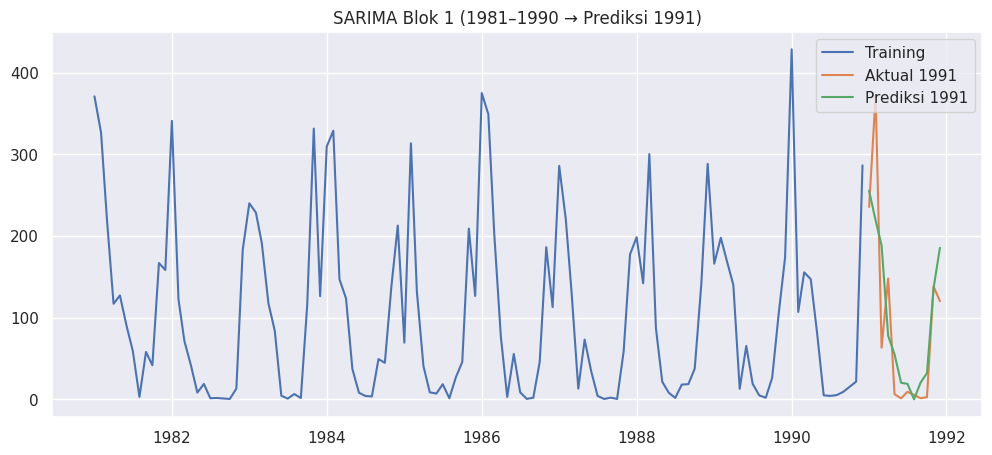

In [ ]:
# ===============================
# SARIMA BLOK 1 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block1 = rain_series.loc['1981-01-01':'1990-12-01']
actual_1991 = rain_series.loc['1991-01-01':'1991-12-01']

print("Jumlah data training:", train_block1.shape)
print("Jumlah data aktual 1991:", actual_1991.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (2,0,1)
seasonal_order = (1,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block1 = SARIMAX(
    train_block1,
    order=order,
    seasonal_order=seasonal_order,
    exog=None,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block1 = model_block1.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block1 = results_block1.predict(
    start=train_block1.index[0],
    end=train_block1.index[-1]
)

mae_train = mean_absolute_error(train_block1, train_pred_block1)
mse_train = mean_squared_error(train_block1, train_pred_block1)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block1 - train_pred_block1) / train_block1)) * 100
r2_train = r2_score(train_block1, train_pred_block1)

print("\n=== ERROR TRAINING BLOK 1 ===")
print("MAE  :", mae_train)
print("MSE  :", mse_train)
print("RMSE :", rmse_train)
print("MAPE :", mape_train)
print("R2   :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block1 = results_block1.forecast(steps=12)

forecast_block1.index = actual_1991.index

forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block1_df = pd.DataFrame({
    'PREDIKSI_1991': forecast_block1
})

print("\n=== HASIL PREDIKSI 12 BULAN (1991) ===")
print(forecast_block1_df)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_1991 = pd.DataFrame({
    'AKTUAL_1991': actual_1991,
    'PREDIKSI_1991': forecast_block1
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_1991)


# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_1991, forecast_block1)
mse_pred = mean_squared_error(actual_1991, forecast_block1)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_1991 - forecast_block1) / actual_1991)) * 100
r2_pred = r2_score(actual_1991, forecast_block1)

print("\n=== ERROR PREDIKSI 1991 ===")
print("MAE  :", mae_pred)
print("MSE  :", mse_pred)
print("RMSE :", rmse_pred)
print("MAPE :", mape_pred)
print("R2   :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 1
# ===============================
sarima_results.append({
    "block": 1,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block1, label='Training')
plt.plot(actual_1991, label='Aktual 1991')
plt.plot(forecast_block1, label='Prediksi 1991')

plt.legend()
plt.title("SARIMA Blok 1 (1981–1990 → Prediksi 1991)")
plt.show()

# BLOK 2

Jumlah data training: (120,)
Jumlah data aktual 1996: (12,)

Training selesai

=== ERROR TRAINING BLOK 2 ===
MAE  : 49.8538
MSE  : 6644.8068
RMSE : 81.5157
MAPE : 238.24%
R2   : 0.3648

=== HASIL PREDIKSI 12 BULAN (1996) ===
            PREDIKSI_1996
DATE                     
1996-01-01         220.68
1996-02-01         218.69
1996-03-01         182.03
1996-04-01         105.47
1996-05-01          26.78
1996-06-01          22.45
1996-07-01           6.80
1996-08-01           4.36
1996-09-01           6.07
1996-10-01          27.79
1996-11-01         113.97
1996-12-01         186.89

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_1996  PREDIKSI_1996
DATE                                  
1996-01-01       184.10         220.68
1996-02-01       244.27         218.69
1996-03-01       127.13         182.03
1996-04-01       131.29         105.47
1996-05-01        21.51          26.78
1996-06-01         6.90          22.45
1996-07-01         2.86           6.80
1996-08-01         

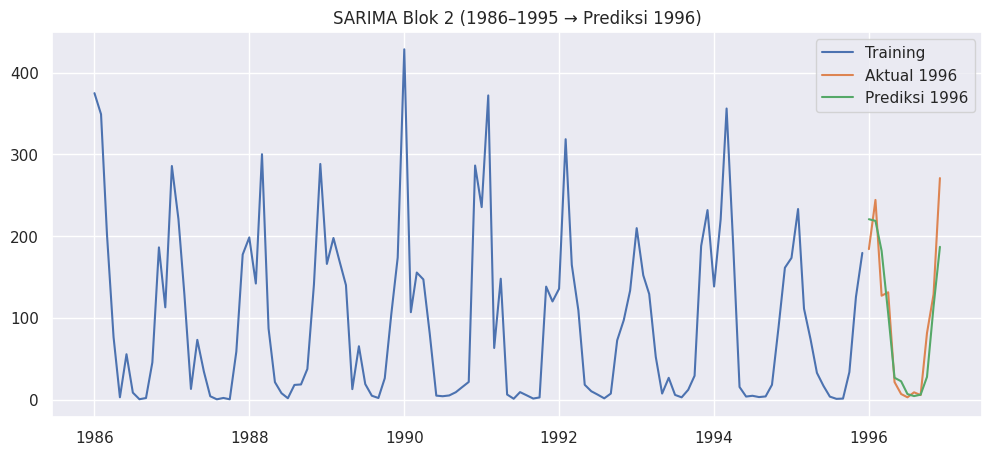

In [ ]:
# ===============================
# SARIMA BLOK 2 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block2 = rain_series.loc['1986-01-01':'1995-12-01']
actual_1996 = rain_series.loc['1996-01-01':'1996-12-01']

print("Jumlah data training:", train_block2.shape)
print("Jumlah data aktual 1996:", actual_1996.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (2,0,1)
seasonal_order = (1,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block2 = SARIMAX(
    train_block2,
    order=order,
    seasonal_order=seasonal_order,
    exog=None,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block2 = model_block2.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block2 = results_block2.predict(
    start=train_block2.index[0],
    end=train_block2.index[-1]
)

mae_train = mean_absolute_error(train_block2, train_pred_block2)
mse_train = mean_squared_error(train_block2, train_pred_block2)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block2 - train_pred_block2) / train_block2)) * 100
r2_train = r2_score(train_block2, train_pred_block2)

print("\n=== ERROR TRAINING BLOK 2 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block2 = results_block2.forecast(steps=12)

forecast_block2.index = actual_1996.index
forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block2_df = pd.DataFrame({
    'PREDIKSI_1996': forecast_block2
})

print("\n=== HASIL PREDIKSI 12 BULAN (1996) ===")
print(forecast_block2_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_1996 = pd.DataFrame({
    'AKTUAL_1996': actual_1996,
    'PREDIKSI_1996': forecast_block2
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_1996.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_1996, forecast_block2)
mse_pred = mean_squared_error(actual_1996, forecast_block2)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_1996 - forecast_block2) / actual_1996)) * 100
r2_pred = r2_score(actual_1996, forecast_block2)

print("\n=== ERROR PREDIKSI 1996 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 2
# ===============================
sarima_results.append({
    "block": 2,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block2, label='Training')
plt.plot(actual_1996, label='Aktual 1996')
plt.plot(forecast_block2, label='Prediksi 1996')

plt.legend()
plt.title("SARIMA Blok 2 (1986–1995 → Prediksi 1996)")
plt.show()

# BLOK 3

Jumlah data training: (120,)
Jumlah data aktual 2001: (12,)

Training selesai

=== ERROR TRAINING BLOK 3 ===
MAE  : 44.7652
MSE  : 5512.4428
RMSE : 74.2458
MAPE : 130.45%
R2   : 0.4401

=== HASIL PREDIKSI 12 BULAN (2001) ===
            PREDIKSI_2001
DATE                     
2001-01-01         239.28
2001-02-01         239.16
2001-03-01         152.20
2001-04-01         134.78
2001-05-01          41.92
2001-06-01          14.69
2001-07-01          22.62
2001-08-01           7.06
2001-09-01          13.89
2001-10-01          80.92
2001-11-01         158.90
2001-12-01         195.72

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2001  PREDIKSI_2001
DATE                                  
2001-01-01       170.44         239.28
2001-02-01       206.45         239.16
2001-03-01       148.22         152.20
2001-04-01       123.70         134.78
2001-05-01        12.01          41.92
2001-06-01        67.58          14.69
2001-07-01         3.32          22.62
2001-08-01         

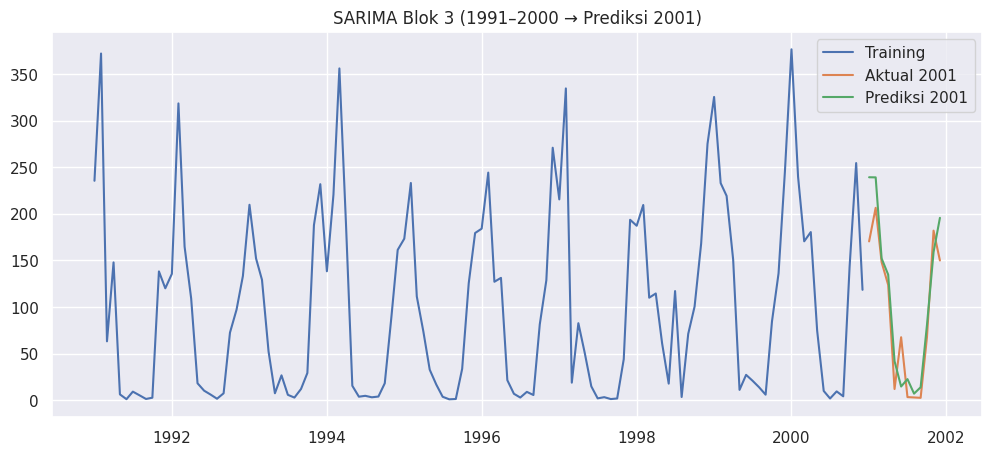

In [ ]:
# ===============================
# SARIMA BLOK 3 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block3 = rain_series.loc['1991-01-01':'2000-12-01']
actual_2001 = rain_series.loc['2001-01-01':'2001-12-01']

print("Jumlah data training:", train_block3.shape)
print("Jumlah data aktual 2001:", actual_2001.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (2,0,1)
seasonal_order = (1,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block3 = SARIMAX(
    train_block3,
    order=order,
    seasonal_order=seasonal_order,
    exog=None,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block3 = model_block3.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block3 = results_block3.predict(
    start=train_block3.index[0],
    end=train_block3.index[-1]
)

mae_train = mean_absolute_error(train_block3, train_pred_block3)
mse_train = mean_squared_error(train_block3, train_pred_block3)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block3 - train_pred_block3) / train_block3)) * 100
r2_train = r2_score(train_block3, train_pred_block3)

print("\n=== ERROR TRAINING BLOK 3 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block3 = results_block3.forecast(steps=12)

forecast_block3.index = actual_2001.index
forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block3_df = pd.DataFrame({
    'PREDIKSI_2001': forecast_block3
})

print("\n=== HASIL PREDIKSI 12 BULAN (2001) ===")
print(forecast_block3_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2001 = pd.DataFrame({
    'AKTUAL_2001': actual_2001,
    'PREDIKSI_2001': forecast_block3
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2001.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2001, forecast_block3)
mse_pred = mean_squared_error(actual_2001, forecast_block3)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2001 - forecast_block3) / actual_2001)) * 100
r2_pred = r2_score(actual_2001, forecast_block3)

print("\n=== ERROR PREDIKSI 2001 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 3
# ===============================
sarima_results.append({
    "block": 3,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block3, label='Training')
plt.plot(actual_2001, label='Aktual 2001')
plt.plot(forecast_block3, label='Prediksi 2001')

plt.legend()
plt.title("SARIMA Blok 3 (1991–2000 → Prediksi 2001)")
plt.show()

# BLOK 4

Jumlah data training: (120,)
Jumlah data aktual 2006: (12,)

Training selesai

=== ERROR TRAINING BLOK 4 ===
MAE  : 47.8002
MSE  : 4647.1661
RMSE : 68.1701
MAPE : 234.37%
R2   : 0.5350

=== HASIL PREDIKSI 12 BULAN (2006) ===
            PREDIKSI_2006
DATE                     
2006-01-01         213.36
2006-02-01         251.88
2006-03-01         154.03
2006-04-01         122.21
2006-05-01          37.42
2006-06-01          19.08
2006-07-01          16.04
2006-08-01           6.24
2006-09-01          10.47
2006-10-01          58.10
2006-11-01         141.20
2006-12-01         221.36

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2006  PREDIKSI_2006
DATE                                  
2006-01-01       221.73         213.36
2006-02-01       231.51         251.88
2006-03-01       198.98         154.03
2006-04-01       168.91         122.21
2006-05-01        73.56          37.42
2006-06-01         4.75          19.08
2006-07-01         1.09          16.04
2006-08-01         

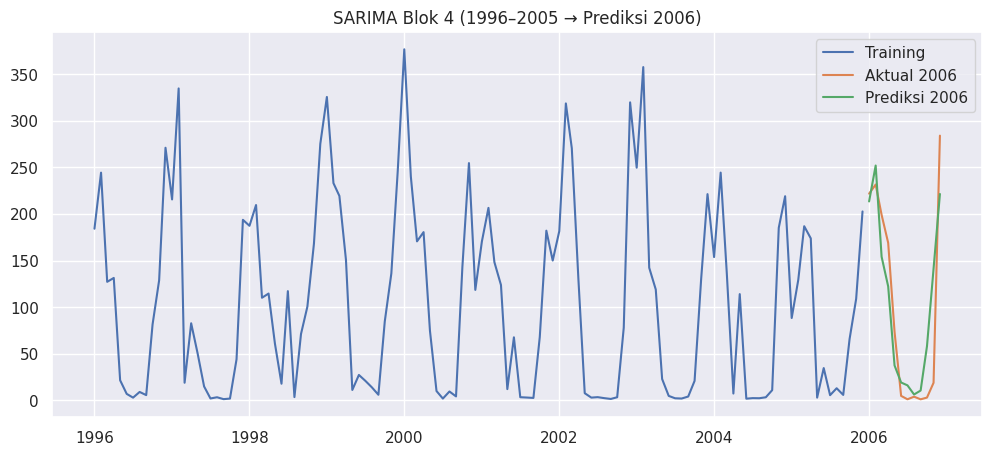

In [ ]:
# ===============================
# SARIMA BLOK 4 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block4 = rain_series.loc['1996-01-01':'2005-12-01']
actual_2006 = rain_series.loc['2006-01-01':'2006-12-01']

print("Jumlah data training:", train_block4.shape)
print("Jumlah data aktual 2006:", actual_2006.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (2,0,1)
seasonal_order = (1,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block4 = SARIMAX(
    train_block4,
    order=order,
    seasonal_order=seasonal_order,
    exog=None,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block4 = model_block4.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block4 = results_block4.predict(
    start=train_block4.index[0],
    end=train_block4.index[-1]
)

mae_train = mean_absolute_error(train_block4, train_pred_block4)
mse_train = mean_squared_error(train_block4, train_pred_block4)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block4 - train_pred_block4) / train_block4)) * 100
r2_train = r2_score(train_block4, train_pred_block4)

print("\n=== ERROR TRAINING BLOK 4 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block4 = results_block4.forecast(steps=12)

forecast_block4.index = actual_2006.index
forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block4_df = pd.DataFrame({
    'PREDIKSI_2006': forecast_block4
})

print("\n=== HASIL PREDIKSI 12 BULAN (2006) ===")
print(forecast_block4_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2006 = pd.DataFrame({
    'AKTUAL_2006': actual_2006,
    'PREDIKSI_2006': forecast_block4
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2006.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2006, forecast_block4)
mse_pred = mean_squared_error(actual_2006, forecast_block4)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2006 - forecast_block4) / actual_2006)) * 100
r2_pred = r2_score(actual_2006, forecast_block4)

print("\n=== ERROR PREDIKSI 2006 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 4
# ===============================
sarima_results.append({
    "block": 4,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block4, label='Training')
plt.plot(actual_2006, label='Aktual 2006')
plt.plot(forecast_block4, label='Prediksi 2006')

plt.legend()
plt.title("SARIMA Blok 4 (1996–2005 → Prediksi 2006)")
plt.show()

# BLOK 5

Jumlah data training: (120,)
Jumlah data aktual 2011: (12,)

Training selesai

=== ERROR TRAINING BLOK 5 ===
MAE  : 49.7585
MSE  : 4880.9658
RMSE : 69.8639
MAPE : 270.79%
R2   : 0.5326

=== HASIL PREDIKSI 12 BULAN (2011) ===
            PREDIKSI_2011
DATE                     
2011-01-01         233.88
2011-02-01         253.37
2011-03-01         205.42
2011-04-01         126.69
2011-05-01          70.11
2011-06-01          37.99
2011-07-01          36.84
2011-08-01          20.03
2011-09-01          49.28
2011-10-01          51.02
2011-11-01         135.77
2011-12-01         253.39

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2011  PREDIKSI_2011
DATE                                  
2011-01-01       252.99         233.88
2011-02-01       214.05         253.37
2011-03-01       172.84         205.42
2011-04-01       231.43         126.69
2011-05-01       159.05          70.11
2011-06-01         0.75          37.99
2011-07-01         0.65          36.84
2011-08-01         

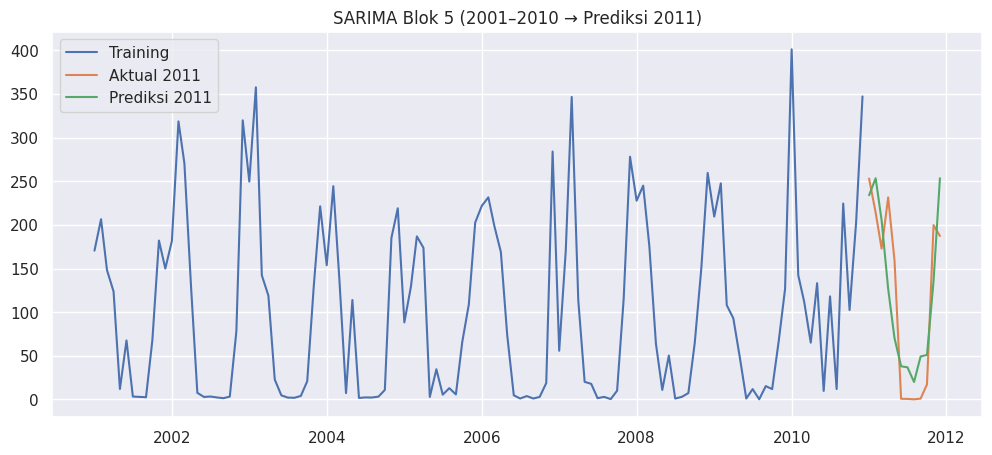

In [ ]:
# ===============================
# SARIMA BLOK 5 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block5 = rain_series.loc['2001-01-01':'2010-12-01']
actual_2011 = rain_series.loc['2011-01-01':'2011-12-01']

print("Jumlah data training:", train_block5.shape)
print("Jumlah data aktual 2011:", actual_2011.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (2,0,1)
seasonal_order = (1,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block5 = SARIMAX(
    train_block5,
    order=order,
    seasonal_order=seasonal_order,
    exog=None,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block5 = model_block5.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block5 = results_block5.predict(
    start=train_block5.index[0],
    end=train_block5.index[-1]
)

mae_train = mean_absolute_error(train_block5, train_pred_block5)
mse_train = mean_squared_error(train_block5, train_pred_block5)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block5 - train_pred_block5) / train_block5)) * 100
r2_train = r2_score(train_block5, train_pred_block5)

print("\n=== ERROR TRAINING BLOK 5 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block5 = results_block5.forecast(steps=12)

forecast_block5.index = actual_2011.index
forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block5_df = pd.DataFrame({
    'PREDIKSI_2011': forecast_block5
})

print("\n=== HASIL PREDIKSI 12 BULAN (2011) ===")
print(forecast_block5_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2011 = pd.DataFrame({
    'AKTUAL_2011': actual_2011,
    'PREDIKSI_2011': forecast_block5
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2011.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2011, forecast_block5)
mse_pred = mean_squared_error(actual_2011, forecast_block5)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2011 - forecast_block5) / actual_2011)) * 100
r2_pred = r2_score(actual_2011, forecast_block5)

print("\n=== ERROR PREDIKSI 2011 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 5
# ===============================
sarima_results.append({
    "block": 5,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block5, label='Training')
plt.plot(actual_2011, label='Aktual 2011')
plt.plot(forecast_block5, label='Prediksi 2011')

plt.legend()
plt.title("SARIMA Blok 5 (2001–2010 → Prediksi 2011)")
plt.show()

# BLOK 6

Jumlah data training: (120,)
Jumlah data aktual 2016: (12,)

Training selesai

=== ERROR TRAINING BLOK 6 ===
MAE  : 56.1936
MSE  : 6779.4267
RMSE : 82.3373
MAPE : 624.41%
R2   : 0.4106

=== HASIL PREDIKSI 12 BULAN (2016) ===
            PREDIKSI_2016
DATE                     
2016-01-01         246.41
2016-02-01         183.26
2016-03-01         183.05
2016-04-01         113.31
2016-05-01          68.04
2016-06-01          19.50
2016-07-01          15.47
2016-08-01           1.01
2016-09-01          24.34
2016-10-01          22.85
2016-11-01         112.10
2016-12-01         239.92

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2016  PREDIKSI_2016
DATE                                  
2016-01-01       264.52         246.41
2016-02-01       414.64         183.26
2016-03-01       158.53         183.05
2016-04-01        98.26         113.31
2016-05-01        56.35          68.04
2016-06-01       115.15          19.50
2016-07-01        66.79          15.47
2016-08-01        1

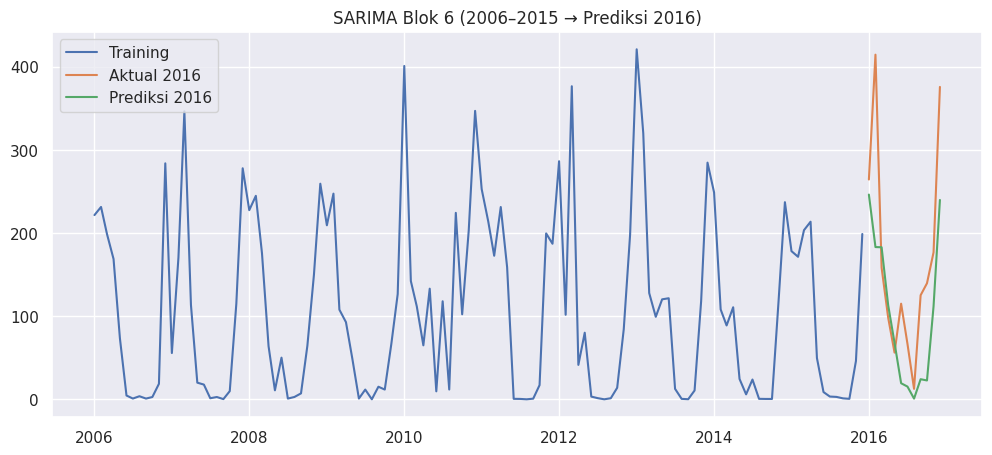

In [ ]:
# ===============================
# SARIMA BLOK 6 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block6 = rain_series.loc['2006-01-01':'2015-12-01']
actual_2016 = rain_series.loc['2016-01-01':'2016-12-01']

print("Jumlah data training:", train_block6.shape)
print("Jumlah data aktual 2016:", actual_2016.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (2,0,1)
seasonal_order = (1,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block6 = SARIMAX(
    train_block6,
    order=order,
    seasonal_order=seasonal_order,
    exog=None,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block6 = model_block6.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block6 = results_block6.predict(
    start=train_block6.index[0],
    end=train_block6.index[-1]
)

mae_train = mean_absolute_error(train_block6, train_pred_block6)
mse_train = mean_squared_error(train_block6, train_pred_block6)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block6 - train_pred_block6) / train_block6)) * 100
r2_train = r2_score(train_block6, train_pred_block6)

print("\n=== ERROR TRAINING BLOK 6 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block6 = results_block6.forecast(steps=12)

forecast_block6.index = actual_2016.index
forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block6_df = pd.DataFrame({
    'PREDIKSI_2016': forecast_block6
})

print("\n=== HASIL PREDIKSI 12 BULAN (2016) ===")
print(forecast_block6_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2016 = pd.DataFrame({
    'AKTUAL_2016': actual_2016,
    'PREDIKSI_2016': forecast_block6
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2016.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2016, forecast_block6)
mse_pred = mean_squared_error(actual_2016, forecast_block6)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2016 - forecast_block6) / actual_2016)) * 100
r2_pred = r2_score(actual_2016, forecast_block6)

print("\n=== ERROR PREDIKSI 2016 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 6
# ===============================
sarima_results.append({
    "block": 6,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block6, label='Training')
plt.plot(actual_2016, label='Aktual 2016')
plt.plot(forecast_block6, label='Prediksi 2016')

plt.legend()
plt.title("SARIMA Blok 6 (2006–2015 → Prediksi 2016)")
plt.show()

# BLOK 7

Jumlah data training: (120,)
Jumlah data aktual 2021: (12,)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Training selesai

=== ERROR TRAINING BLOK 7 ===
MAE  : 59.9632
MSE  : 7713.3652
RMSE : 87.8258
MAPE : 257.07%
R2   : 0.4229

=== HASIL PREDIKSI 12 BULAN (2021) ===
            PREDIKSI_2021
DATE                     
2021-01-01         311.26
2021-02-01         249.85
2021-03-01         209.47
2021-04-01         120.48
2021-05-01          65.66
2021-06-01          37.19
2021-07-01          13.77
2021-08-01           9.66
2021-09-01          16.08
2021-10-01          35.25
2021-11-01         142.28
2021-12-01         234.02

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2021  PREDIKSI_2021
DATE                                  
2021-01-01       317.18         311.26
2021-02-01       362.96         249.85
2021-03-01       183.83         209.47
2021-04-01        96.28         120.48
2021-05-01        22.04          65.66
2021-06-01        61.22          37.19
2021-07-01         8.63          13.77
2021-08-01        11.91           9.66
2021-09-01        72.10          16.08
2

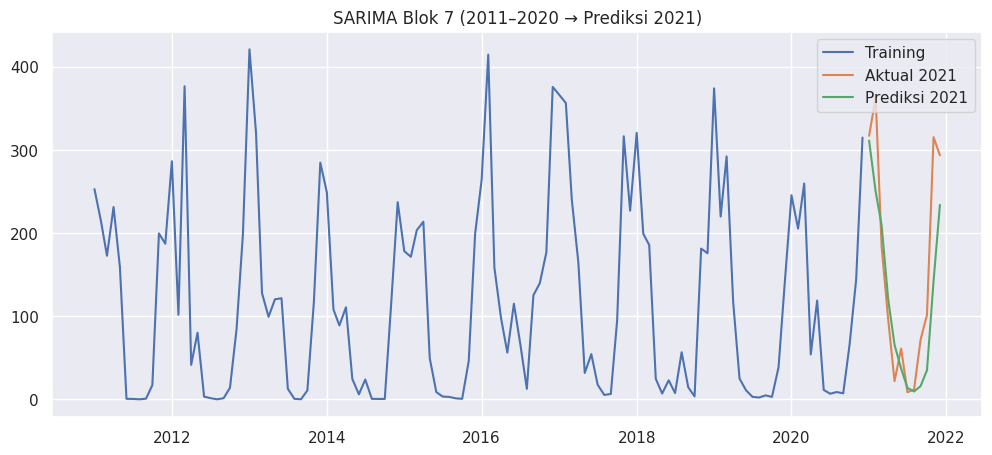

In [ ]:
# ===============================
# SARIMA BLOK 7 (FULL 1 CELL)
# ===============================

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# DATA TRAINING & AKTUAL
# ===============================
train_block7 = rain_series.loc['2011-01-01':'2020-12-01']
actual_2021 = rain_series.loc['2021-01-01':'2021-12-01']

print("Jumlah data training:", train_block7.shape)
print("Jumlah data aktual 2021:", actual_2021.shape)

# ===============================
# DEFINISI MODEL (FIX)
# ===============================
order = (2,0,1)
seasonal_order = (1,1,1,12)

# ===============================
# TRAINING
# ===============================
model_block7 = SARIMAX(
    train_block7,
    order=order,
    seasonal_order=seasonal_order,
    exog=None,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_block7 = model_block7.fit(disp=False)

print("\nTraining selesai")

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_block7 = results_block7.predict(
    start=train_block7.index[0],
    end=train_block7.index[-1]
)

mae_train = mean_absolute_error(train_block7, train_pred_block7)
mse_train = mean_squared_error(train_block7, train_pred_block7)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((train_block7 - train_pred_block7) / train_block7)) * 100
r2_train = r2_score(train_block7, train_pred_block7)

print("\n=== ERROR TRAINING BLOK 7 ===")
print(f"MAE  : {mae_train:.4f}")
print(f"MSE  : {mse_train:.4f}")
print(f"RMSE : {rmse_train:.4f}")
print(f"MAPE : {mape_train:.2f}%")
print(f"R2   : {r2_train:.4f}")

# ===============================
# PREDIKSI 12 BULAN
# ===============================
forecast_block7 = results_block7.forecast(steps=12)

forecast_block7.index = actual_2021.index
forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block7_df = pd.DataFrame({
    'PREDIKSI_2021': forecast_block7
})

print("\n=== HASIL PREDIKSI 12 BULAN (2021) ===")
print(forecast_block7_df.round(2).to_string())

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2021 = pd.DataFrame({
    'AKTUAL_2021': actual_2021,
    'PREDIKSI_2021': forecast_block7
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2021.round(2).to_string())

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2021, forecast_block7)
mse_pred = mean_squared_error(actual_2021, forecast_block7)
rmse_pred = np.sqrt(mse_pred)
mape_pred = np.mean(np.abs((actual_2021 - forecast_block7) / actual_2021)) * 100
r2_pred = r2_score(actual_2021, forecast_block7)

print("\n=== ERROR PREDIKSI 2021 ===")
print(f"MAE  : {mae_pred:.4f}")
print(f"MSE  : {mse_pred:.4f}")
print(f"RMSE : {rmse_pred:.4f}")
print(f"MAPE : {mape_pred:.2f}%")
print(f"R2   : {r2_pred:.4f}")

# ===============================
# SIMPAN HASIL BLOK 7
# ===============================
sarima_results.append({
    "block": 7,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "MAPE_Train": mape_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "MAPE_Pred": mape_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block7, label='Training')
plt.plot(actual_2021, label='Aktual 2021')
plt.plot(forecast_block7, label='Prediksi 2021')

plt.legend()
plt.title("SARIMA Blok 7 (2011–2020 → Prediksi 2021)")
plt.show()

# BLOK 8

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


PREDIKSI 2026
              Prediksi
2026-01-01  287.947534
2026-02-01  248.371011
2026-03-01  244.224729
2026-04-01  100.468910
2026-05-01   56.353255
2026-06-01   41.429612
2026-07-01   21.203067
2026-08-01   12.314526
2026-09-01   36.826646
2026-10-01   76.048131
2026-11-01  181.654615
2026-12-01  263.984879


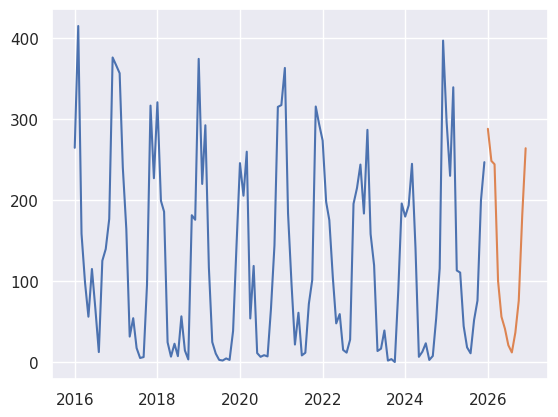

In [ ]:
# SARIMA BLOK 8

train_block = rain_series.loc['2016-01-01':'2025-12-01']

model = SARIMAX(train_block, order=(2,0,1), seasonal_order=(1,1,1,12))
results = model.fit(disp=False)

forecast = results.forecast(steps=12)

print("PREDIKSI 2026")
print(pd.DataFrame({'Prediksi':forecast}))

plt.plot(train_block)
plt.plot(forecast)
plt.show()

# REKAP SARIMA (RATA-RATA)

In [ ]:
# ===============================
# REKAP RATA-RATA SARIMA
# ===============================

import numpy as np

# TRAINING
mae_train_list = [res['MAE_Train'] for res in sarima_results]
mse_train_list = [res['MSE_Train'] for res in sarima_results]
rmse_train_list = [res['RMSE_Train'] for res in sarima_results]
mape_train_list = [res['MAPE_Train'] for res in sarima_results]
r2_train_list = [res['R2_Train'] for res in sarima_results]

# PREDIKSI
mae_pred_list = [res['MAE_Pred'] for res in sarima_results]
mse_pred_list = [res['MSE_Pred'] for res in sarima_results]
rmse_pred_list = [res['RMSE_Pred'] for res in sarima_results]
mape_pred_list = [res['MAPE_Pred'] for res in sarima_results]
r2_pred_list = [res['R2_Pred'] for res in sarima_results]

# ===============================
# PRINT HASIL RAPI
# ===============================

print("=== RATA-RATA SARIMA DENGAN ORDER 2,0,1 ===")

print("\n--- TRAINING ---")
print(f"MAE  : {np.mean(mae_train_list):.4f}")
print(f"MSE  : {np.mean(mse_train_list):.4f}")
print(f"RMSE : {np.mean(rmse_train_list):.4f}")
print(f"MAPE : {np.mean(mape_train_list):.2f}%")
print(f"R2   : {np.mean(r2_train_list):.4f}")

print("\n--- PREDIKSI ---")
print(f"MAE  : {np.mean(mae_pred_list):.4f}")
print(f"MSE  : {np.mean(mse_pred_list):.4f}")
print(f"RMSE : {np.mean(rmse_pred_list):.4f}")
print(f"MAPE : {np.mean(mape_pred_list):.2f}%")
print(f"R2   : {np.mean(r2_pred_list):.4f}")

=== RATA-RATA SARIMA DENGAN ORDER 2,0,1 ===

--- TRAINING ---
MAE  : 53.7057
MSE  : 6877.4580
RMSE : 81.9055
MAPE : 345.03%
R2   : 0.3815

--- PREDIKSI ---
MAE  : 44.2149
MSE  : 3788.9957
RMSE : 58.0772
MAPE : 492.43%
R2   : 0.6895


# AMBP


In [ ]:
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

In [ ]:
# ===============================
# AMBP MODEL SELECTION
# ===============================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Gunakan data training awal (blok 1 saja dulu)
train_data = rain_series['1981-01-01':'1990-12-01']

# Scaling
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_data.values.reshape(-1,1))

# Split internal (untuk validasi)
split = int(len(train_scaled)*0.8)
train_part = train_scaled[:split]
val_part = train_scaled[split:]

# Kandidat parameter
lags = [6, 12]
neurons = [(10,), (20,), (20,10)]
activations = ['relu', 'tanh']

results = []

for lag in lags:
    # Buat lagged data
    X_train, y_train = create_lagged_data(train_part, lag)
    X_val, y_val = create_lagged_data(val_part, lag)

    for neuron in neurons:
        for act in activations:
            try:
                model = MLPRegressor(
                    hidden_layer_sizes=neuron,
                    activation=act,
                    solver='adam',
                    max_iter=2000,
                    early_stopping=True,
                    random_state=42
                )

                model.fit(X_train, y_train.ravel())

                pred_val = model.predict(X_val)

                rmse = np.sqrt(mean_squared_error(y_val, pred_val))

                results.append({
                    'lag': lag,
                    'neuron': neuron,
                    'activation': act,
                    'RMSE': rmse
                })

            except:
                pass

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='RMSE')

print(results_df)

    lag    neuron activation      RMSE
2     6     (20,)       relu  0.185611
3     6     (20,)       tanh  0.196226
1     6     (10,)       tanh  0.208680
4     6  (20, 10)       relu  0.223926
6    12     (10,)       relu  0.227637
10   12  (20, 10)       relu  0.230077
0     6     (10,)       relu  0.232952
9    12     (20,)       tanh  0.233151
7    12     (10,)       tanh  0.236645
5     6  (20, 10)       tanh  0.247905
11   12  (20, 10)       tanh  0.264286
8    12     (20,)       relu  0.283625


In [ ]:
best_config = results_df.iloc[0]

best_lag = int(best_config['lag'])
best_neuron = best_config['neuron']
best_activation = best_config['activation']

print("\n=== BEST AMBP CONFIG ===")
print(best_config)


=== BEST AMBP CONFIG ===
lag                  6
neuron           (20,)
activation        relu
RMSE          0.185611
Name: 2, dtype: object


# BLOK 1

In [ ]:
ambp_results = []

Training size: (120,)
Actual 1991 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 402

=== ERROR TRAINING BLOK 1 ===
MAE : 39.99958202438908
MSE : 3701.2968452355544
RMSE: 60.83828437123744
R2  : 0.6732258064662442

=== HASIL PREDIKSI 12 BULAN (1991) ===
DATE
1991-01-01    158.240635
1991-02-01    183.393650
1991-03-01    127.588392
1991-04-01     94.642757
1991-05-01     36.156207
1991-06-01     13.866968
1991-07-01      8.803195
1991-08-01      7.565777
1991-09-01      5.532882
1991-10-01     10.441953
1991-11-01     24.569769
1991-12-01    158.053085
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_1991  PREDIKSI_1991
DATE                                  
1991-01-01       235.49     158.240635
1991-02-01       372.08     183.393650
1991-03-01        63.19     127.588392
1991-04-01       147.90      94.642757
1991-05-01         6.26      36.156207
1991-06-01         1.11      13.866968
1991-07-01         9.20       8

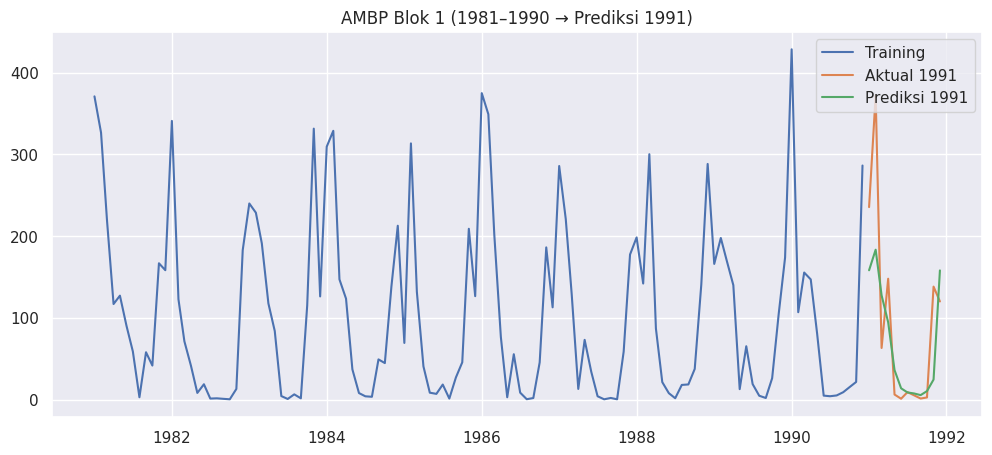

In [ ]:
# ==============================
# AMBP BLOK 1
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block1 = rain_series['1981-01-01':'1990-12-01']
actual_1991 = rain_series['1991-01-01':'1991-12-01']

# LOG TRANSFORM
train_block1_log = np.log1p(train_block1)

print("Training size:", train_block1.shape)
print("Actual 1991 size:", actual_1991.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block1 = MinMaxScaler()

train_scaled_block1 = scaler_block1.fit_transform(
    train_block1_log.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b1, y_train_b1 = create_lagged_data(train_scaled_block1, lag)

print("X shape:", X_train_b1.shape)
print("y shape:", y_train_b1.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b1 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b1.fit(X_train_b1, y_train_b1.ravel())

print("\nTraining selesai")

print("Iterations:", model_b1.n_iter_)

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_scaled = model_b1.predict(X_train_b1)

train_pred = scaler_block1.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block1.inverse_transform(y_train_b1)

train_pred = np.expm1(train_pred)
train_actual = np.expm1(train_actual)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 1 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block1[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b1.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block1 = scaler_block1.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block1 = np.expm1(forecast_block1)

forecast_block1 = np.maximum(forecast_block1, 0)

forecast_block1 = pd.Series(
    forecast_block1,
    index=actual_1991.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (1991) ===")
print(forecast_block1)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_1991 = pd.DataFrame({
    'AKTUAL_1991': actual_1991,
    'PREDIKSI_1991': forecast_block1
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_1991)

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_1991, forecast_block1)
mse_pred = mean_squared_error(actual_1991, forecast_block1)
rmse_pred = np.sqrt(mse_pred)
r2_pred = r2_score(actual_1991, forecast_block1)

print("\n=== ERROR PREDIKSI 1991 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("R2  :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 1
# ===============================
mae_train_b1 = mae_train
mse_train_b1 = mse_train
rmse_train_b1 = rmse_train
r2_train_b1 = r2_train

mae_pred_b1 = mae_pred
mse_pred_b1 = mse_pred
rmse_pred_b1 = rmse_pred
r2_pred_b1 = r2_pred

ambp_results.append({
    "block": 1,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block1.index, train_block1, label="Training")
plt.plot(actual_1991.index, actual_1991, label="Aktual 1991")
plt.plot(forecast_block1.index, forecast_block1, label="Prediksi 1991")

plt.title("AMBP Blok 1 (1981–1990 → Prediksi 1991)")
plt.legend()
plt.show()


# BLOK 2

Training size: (120,)
Actual 1996 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 546

=== ERROR TRAINING BLOK 2 ===
MAE : 34.81615179158694
MSE : 2790.5445879228355
RMSE: 52.8256054193687
R2  : 0.7140551571603755

=== HASIL PREDIKSI 12 BULAN (1996) ===
DATE
1996-01-01    195.121892
1996-02-01    222.009925
1996-03-01    195.928706
1996-04-01     78.248839
1996-05-01     19.495103
1996-06-01      9.689076
1996-07-01      4.266655
1996-08-01      2.321272
1996-09-01      6.504471
1996-10-01     28.375325
1996-11-01    117.652570
1996-12-01    220.625299
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_1996  PREDIKSI_1996
DATE                                  
1996-01-01       184.10     195.121892
1996-02-01       244.27     222.009925
1996-03-01       127.13     195.928706
1996-04-01       131.29      78.248839
1996-05-01        21.51      19.495103
1996-06-01         6.90       9.689076
1996-07-01         2.86       4.

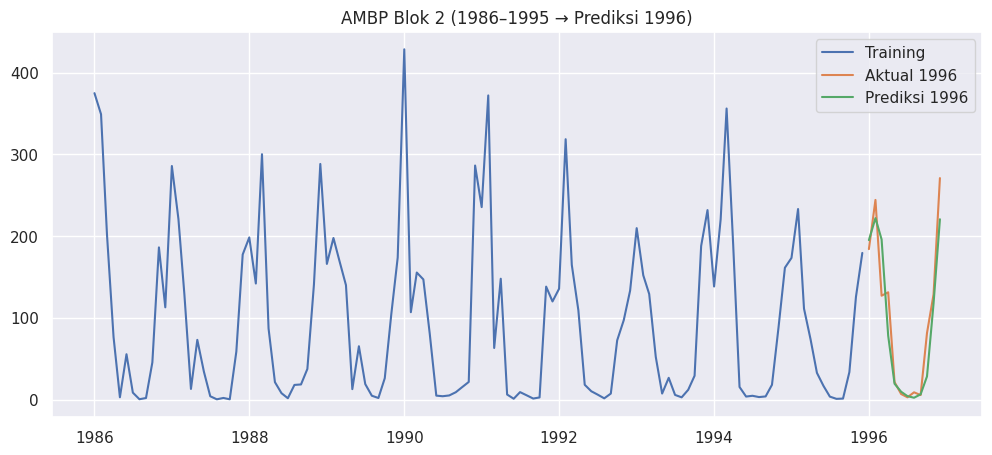

In [ ]:
# ==============================
# AMBP BLOK 2 (FULL 1 CELL)
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block2 = rain_series['1986-01-01':'1995-12-01']
actual_1996 = rain_series['1996-01-01':'1996-12-01']

# LOG TRANSFORM
train_block2_log = np.log1p(train_block2)

print("Training size:", train_block2.shape)
print("Actual 1996 size:", actual_1996.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block2 = MinMaxScaler()

train_scaled_block2 = scaler_block2.fit_transform(
    train_block2_log.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b2, y_train_b2 = create_lagged_data(train_scaled_block2, lag)

print("X shape:", X_train_b2.shape)
print("y shape:", y_train_b2.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b2 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b2.fit(X_train_b2, y_train_b2.ravel())

print("\nTraining selesai")

print("Iterations:", model_b2.n_iter_)

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_scaled = model_b2.predict(X_train_b2)

train_pred = scaler_block2.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block2.inverse_transform(y_train_b2)

train_pred = np.expm1(train_pred)
train_actual = np.expm1(train_actual)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 2 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block2[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b2.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block2 = scaler_block2.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block2 = np.expm1(forecast_block2)

forecast_block2 = np.maximum(forecast_block2, 0)

forecast_block2 = pd.Series(
    forecast_block2,
    index=actual_1996.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (1996) ===")
print(forecast_block2)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_1996 = pd.DataFrame({
    'AKTUAL_1996': actual_1996,
    'PREDIKSI_1996': forecast_block2
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_1996)

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_1996, forecast_block2)
mse_pred = mean_squared_error(actual_1996, forecast_block2)
rmse_pred = np.sqrt(mse_pred)
r2_pred = r2_score(actual_1996, forecast_block2)

print("\n=== ERROR PREDIKSI 1996 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("R2  :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 2
# ===============================
mae_train_b2 = mae_train
mse_train_b2 = mse_train
rmse_train_b2 = rmse_train
r2_train_b2 = r2_train

mae_pred_b2 = mae_pred
mse_pred_b2 = mse_pred
rmse_pred_b2 = rmse_pred
r2_pred_b2 = r2_pred

ambp_results.append({
    "block": 2,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block2.index, train_block2, label="Training")
plt.plot(actual_1996.index, actual_1996, label="Aktual 1996")
plt.plot(forecast_block2.index, forecast_block2, label="Prediksi 1996")

plt.title("AMBP Blok 2 (1986–1995 → Prediksi 1996)")
plt.legend()
plt.show()

# BLOK 3

Training size: (120,)
Actual 2001 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 171

=== ERROR TRAINING BLOK 3 ===
MAE : 51.52706805272193
MSE : 6986.737735875814
RMSE: 83.58670788992598
R2  : 0.2662294289700641

=== HASIL PREDIKSI 12 BULAN (2001) ===
DATE
2001-01-01    236.778623
2001-02-01    124.807387
2001-03-01     48.415355
2001-04-01     30.354729
2001-05-01     14.415089
2001-06-01     19.923424
2001-07-01     11.901060
2001-08-01     22.474294
2001-09-01     27.648647
2001-10-01     73.809661
2001-11-01    166.775511
2001-12-01    145.772921
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2001  PREDIKSI_2001
DATE                                  
2001-01-01       170.44     236.778623
2001-02-01       206.45     124.807387
2001-03-01       148.22      48.415355
2001-04-01       123.70      30.354729
2001-05-01        12.01      14.415089
2001-06-01        67.58      19.923424
2001-07-01         3.32      11.

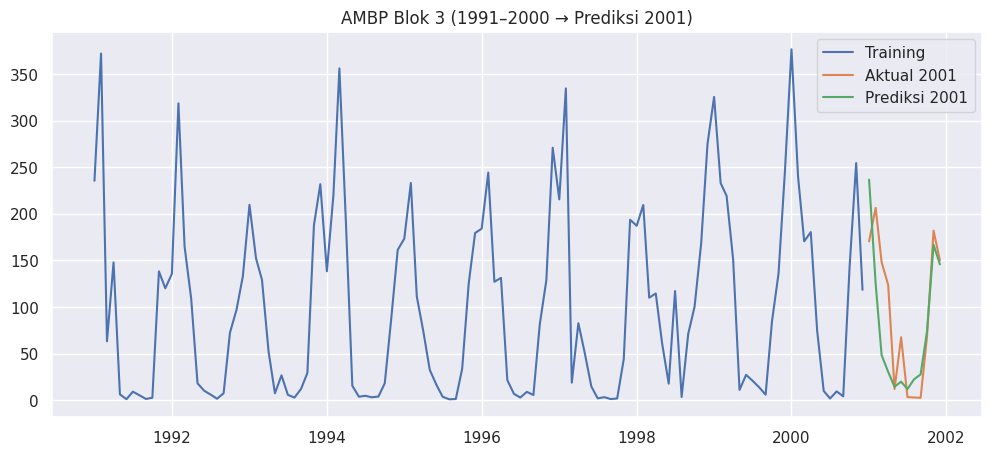

In [ ]:
# ==============================
# AMBP BLOK 3 (FULL 1 CELL)
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block3 = rain_series['1991-01-01':'2000-12-01']
actual_2001 = rain_series['2001-01-01':'2001-12-01']

# LOG TRANSFORM
train_block3_log = np.log1p(train_block3)

print("Training size:", train_block3.shape)
print("Actual 2001 size:", actual_2001.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block3 = MinMaxScaler()

train_scaled_block3 = scaler_block3.fit_transform(
    train_block3_log.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b3, y_train_b3 = create_lagged_data(train_scaled_block3, lag)

print("X shape:", X_train_b3.shape)
print("y shape:", y_train_b3.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b3 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b3.fit(X_train_b3, y_train_b3.ravel())

print("\nTraining selesai")

print("Iterations:", model_b3.n_iter_)

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_scaled = model_b3.predict(X_train_b3)

train_pred = scaler_block3.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block3.inverse_transform(y_train_b3)

train_pred = np.expm1(train_pred)
train_actual = np.expm1(train_actual)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 3 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block3[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b3.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block3 = scaler_block3.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block3 = np.expm1(forecast_block3)

forecast_block3 = np.maximum(forecast_block3, 0)

forecast_block3 = pd.Series(
    forecast_block3,
    index=actual_2001.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (2001) ===")
print(forecast_block3)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2001 = pd.DataFrame({
    'AKTUAL_2001': actual_2001,
    'PREDIKSI_2001': forecast_block3
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2001)

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2001, forecast_block3)
mse_pred = mean_squared_error(actual_2001, forecast_block3)
rmse_pred = np.sqrt(mse_pred)
r2_pred = r2_score(actual_2001, forecast_block3)

print("\n=== ERROR PREDIKSI 2001 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("R2  :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 3
# ===============================
mae_train_b3 = mae_train
mse_train_b3 = mse_train
rmse_train_b3 = rmse_train
r2_train_b3 = r2_train

mae_pred_b3 = mae_pred
mse_pred_b3 = mse_pred
rmse_pred_b3 = rmse_pred
r2_pred_b3 = r2_pred

ambp_results.append({
    "block": 3,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block3.index, train_block3, label="Training")
plt.plot(actual_2001.index, actual_2001, label="Aktual 2001")
plt.plot(forecast_block3.index, forecast_block3, label="Prediksi 2001")

plt.title("AMBP Blok 3 (1991–2000 → Prediksi 2001)")
plt.legend()
plt.show()

# BLOK 4

Training size: (120,)
Actual 2006 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 426

=== ERROR TRAINING BLOK 4 ===
MAE : 38.690297267239195
MSE : 2971.969772104507
RMSE: 54.515775442568064
R2  : 0.7076247649327435

=== HASIL PREDIKSI 12 BULAN (2006) ===
DATE
2006-01-01    175.376356
2006-02-01    164.417378
2006-03-01     71.525243
2006-04-01     70.012806
2006-05-01     14.419465
2006-06-01     11.253826
2006-07-01      5.613280
2006-08-01     10.452634
2006-09-01     10.991938
2006-10-01     78.659014
2006-11-01    164.838217
2006-12-01    132.223449
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2006  PREDIKSI_2006
DATE                                  
2006-01-01       221.73     175.376356
2006-02-01       231.51     164.417378
2006-03-01       198.98      71.525243
2006-04-01       168.91      70.012806
2006-05-01        73.56      14.419465
2006-06-01         4.75      11.253826
2006-07-01         1.09       

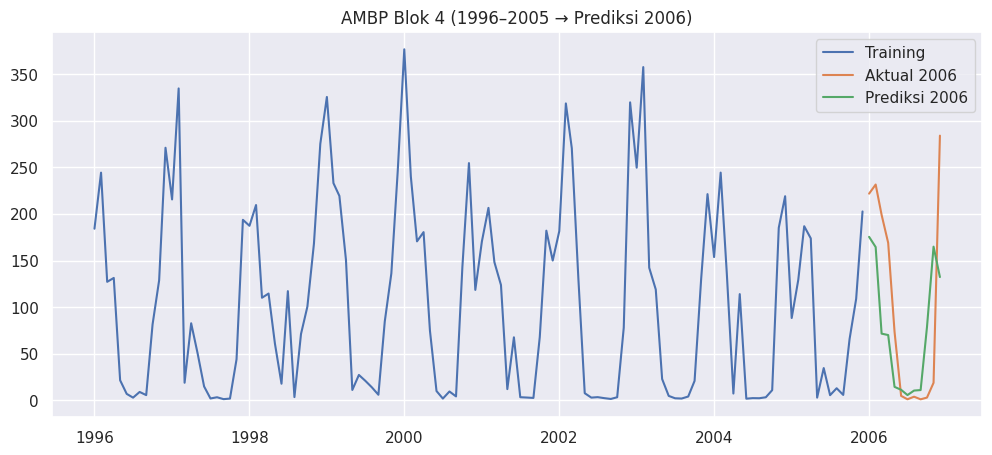

In [ ]:
# ==============================
# AMBP BLOK 4 (FULL 1 CELL)
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block4 = rain_series['1996-01-01':'2005-12-01']
actual_2006 = rain_series['2006-01-01':'2006-12-01']

# LOG TRANSFORM
train_block4_log = np.log1p(train_block4)

print("Training size:", train_block4.shape)
print("Actual 2006 size:", actual_2006.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block4 = MinMaxScaler()

train_scaled_block4 = scaler_block4.fit_transform(
    train_block4_log.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b4, y_train_b4 = create_lagged_data(train_scaled_block4, lag)

print("X shape:", X_train_b4.shape)
print("y shape:", y_train_b4.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b4 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b4.fit(X_train_b4, y_train_b4.ravel())

print("\nTraining selesai")

print("Iterations:", model_b4.n_iter_)

# ===============================
# ERROR TRAINING (5 PARAMETER)
# ===============================
train_pred_scaled = model_b4.predict(X_train_b4)

train_pred = scaler_block4.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block4.inverse_transform(y_train_b4)

train_pred = np.expm1(train_pred)
train_actual = np.expm1(train_actual)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 4 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block4[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b4.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block4 = scaler_block4.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block4 = np.expm1(forecast_block4)

forecast_block4 = np.maximum(forecast_block4, 0)

forecast_block4 = pd.Series(
    forecast_block4,
    index=actual_2006.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (2006) ===")
print(forecast_block4)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2006 = pd.DataFrame({
    'AKTUAL_2006': actual_2006,
    'PREDIKSI_2006': forecast_block4
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2006)

# ===============================
# ERROR PREDIKSI (5 PARAMETER)
# ===============================
mae_pred = mean_absolute_error(actual_2006, forecast_block4)
mse_pred = mean_squared_error(actual_2006, forecast_block4)
rmse_pred = np.sqrt(mse_pred)
r2_pred = r2_score(actual_2006, forecast_block4)

print("\n=== ERROR PREDIKSI 2006 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("R2  :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 4
# ===============================
mae_train_b4 = mae_train
mse_train_b4 = mse_train
rmse_train_b4 = rmse_train
r2_train_b4 = r2_train

mae_pred_b4 = mae_pred
mse_pred_b4 = mse_pred
rmse_pred_b4 = rmse_pred
r2_pred_b4 = r2_pred

ambp_results.append({
    "block": 4,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block4.index, train_block4, label="Training")
plt.plot(actual_2006.index, actual_2006, label="Aktual 2006")
plt.plot(forecast_block4.index, forecast_block4, label="Prediksi 2006")

plt.title("AMBP Blok 4 (1996–2005 → Prediksi 2006)")
plt.legend()
plt.show()

# BLOK 5

Training size: (120,)
Actual 2011 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 175

=== ERROR TRAINING BLOK 5 ===
MAE : 48.992753955157255
MSE : 5933.006373571341
RMSE: 77.02601101946888
R2  : 0.45986085382026576

=== HASIL PREDIKSI 12 BULAN (2011) ===
DATE
2011-01-01    196.004682
2011-02-01     48.311845
2011-03-01     25.233061
2011-04-01      6.622605
2011-05-01     12.837158
2011-06-01      5.962889
2011-07-01     25.157376
2011-08-01     27.140276
2011-09-01    171.190302
2011-10-01    204.248328
2011-11-01    221.499165
2011-12-01    122.937673
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2011  PREDIKSI_2011
DATE                                  
2011-01-01       252.99     196.004682
2011-02-01       214.05      48.311845
2011-03-01       172.84      25.233061
2011-04-01       231.43       6.622605
2011-05-01       159.05      12.837158
2011-06-01         0.75       5.962889
2011-07-01         0.65      2

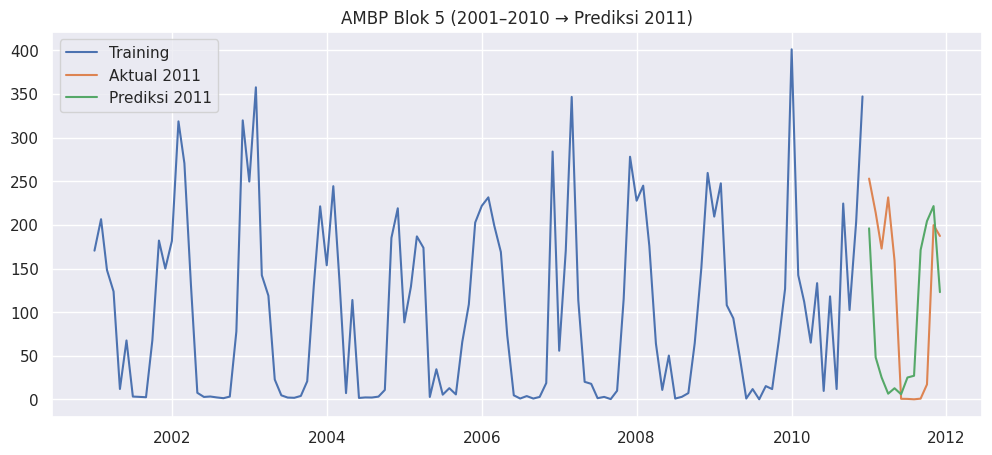

In [ ]:
# ==============================
# AMBP BLOK 5 (FULL 1 CELL)
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block5 = rain_series['2001-01-01':'2010-12-01']
actual_2011 = rain_series['2011-01-01':'2011-12-01']

# LOG TRANSFORM
train_block5_log = np.log1p(train_block5)

print("Training size:", train_block5.shape)
print("Actual 2011 size:", actual_2011.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block5 = MinMaxScaler()

train_scaled_block5 = scaler_block5.fit_transform(
    train_block5_log.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b5, y_train_b5 = create_lagged_data(train_scaled_block5, lag)

print("X shape:", X_train_b5.shape)
print("y shape:", y_train_b5.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b5 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b5.fit(X_train_b5, y_train_b5.ravel())

print("\nTraining selesai")

print("Iterations:", model_b5.n_iter_)

# ===============================
# ERROR TRAINING
# ===============================
train_pred_scaled = model_b5.predict(X_train_b5)

train_pred = scaler_block5.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block5.inverse_transform(y_train_b5)

train_pred = np.expm1(train_pred)
train_actual = np.expm1(train_actual)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 5 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block5[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b5.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block5 = scaler_block5.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block5 = np.expm1(forecast_block5)

forecast_block5 = np.maximum(forecast_block5, 0)

forecast_block5 = pd.Series(
    forecast_block5,
    index=actual_2011.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (2011) ===")
print(forecast_block5)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2011 = pd.DataFrame({
    'AKTUAL_2011': actual_2011,
    'PREDIKSI_2011': forecast_block5
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2011)

# ===============================
# ERROR PREDIKSI
# ===============================
mae_pred = mean_absolute_error(actual_2011, forecast_block5)
mse_pred = mean_squared_error(actual_2011, forecast_block5)
rmse_pred = np.sqrt(mse_pred)
r2_pred = r2_score(actual_2011, forecast_block5)

print("\n=== ERROR PREDIKSI 2011 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("R2  :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 5
# ===============================
mae_train_b5 = mae_train
mse_train_b5 = mse_train
rmse_train_b5 = rmse_train
r2_train_b5 = r2_train

mae_pred_b5 = mae_pred
mse_pred_b5 = mse_pred
rmse_pred_b5 = rmse_pred
r2_pred_b5 = r2_pred

ambp_results.append({
    "block": 5,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block5.index, train_block5, label="Training")
plt.plot(actual_2011.index, actual_2011, label="Aktual 2011")
plt.plot(forecast_block5.index, forecast_block5, label="Prediksi 2011")

plt.title("AMBP Blok 5 (2001–2010 → Prediksi 2011)")
plt.legend()
plt.show()

# BLOK 6

Training size: (120,)
Actual 2016 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 258

=== ERROR TRAINING BLOK 6 ===
MAE : 46.76534812879246
MSE : 5001.259414436561
RMSE: 70.71958296282976
R2  : 0.5661160501353756

=== HASIL PREDIKSI 12 BULAN (2016) ===
DATE
2016-01-01    279.030929
2016-02-01    170.638289
2016-03-01    263.679705
2016-04-01    166.175088
2016-05-01     68.549422
2016-06-01     19.207881
2016-07-01     11.329864
2016-08-01      5.148801
2016-09-01      2.703927
2016-10-01      3.658800
2016-11-01     46.905683
2016-12-01    150.187414
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2016  PREDIKSI_2016
DATE                                  
2016-01-01       264.52     279.030929
2016-02-01       414.64     170.638289
2016-03-01       158.53     263.679705
2016-04-01        98.26     166.175088
2016-05-01        56.35      68.549422
2016-06-01       115.15      19.207881
2016-07-01        66.79      11.

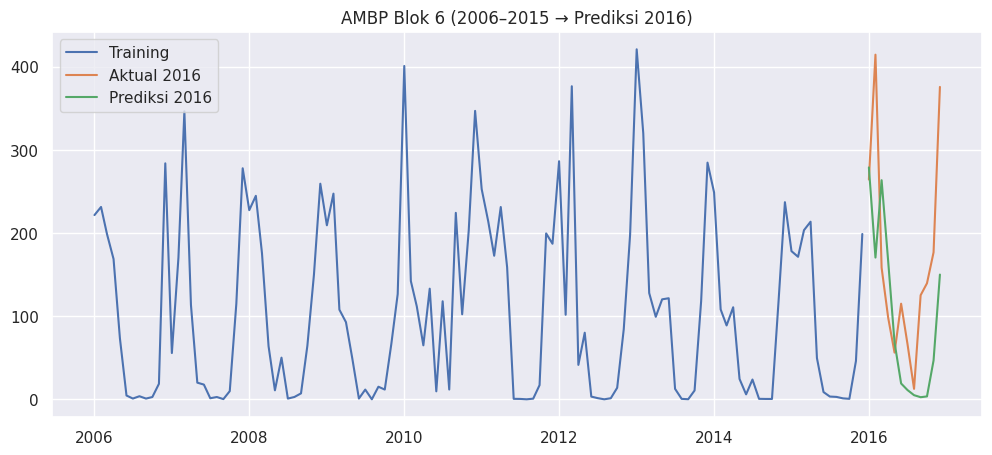

In [ ]:
# ==============================
# AMBP BLOK 6 (FULL 1 CELL)
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block6 = rain_series['2006-01-01':'2015-12-01']
actual_2016 = rain_series['2016-01-01':'2016-12-01']

# LOG TRANSFORM
train_block6_log = np.log1p(train_block6)

print("Training size:", train_block6.shape)
print("Actual 2016 size:", actual_2016.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block6 = MinMaxScaler()

train_scaled_block6 = scaler_block6.fit_transform(
    train_block6_log.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b6, y_train_b6 = create_lagged_data(train_scaled_block6, lag)

print("X shape:", X_train_b6.shape)
print("y shape:", y_train_b6.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b6 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b6.fit(X_train_b6, y_train_b6.ravel())

print("\nTraining selesai")

print("Iterations:", model_b6.n_iter_)

# ===============================
# ERROR TRAINING
# ===============================
train_pred_scaled = model_b6.predict(X_train_b6)

train_pred = scaler_block6.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block6.inverse_transform(y_train_b6)

train_pred = np.expm1(train_pred)
train_actual = np.expm1(train_actual)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 6 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block6[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b6.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block6 = scaler_block6.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block6 = np.expm1(forecast_block6)

forecast_block6 = np.maximum(forecast_block6, 0)

forecast_block6 = pd.Series(
    forecast_block6,
    index=actual_2016.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (2016) ===")
print(forecast_block6)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2016 = pd.DataFrame({
    'AKTUAL_2016': actual_2016,
    'PREDIKSI_2016': forecast_block6
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2016)

# ===============================
# ERROR PREDIKSI
# ===============================
mae_pred = mean_absolute_error(actual_2016, forecast_block6)
mse_pred = mean_squared_error(actual_2016, forecast_block6)
rmse_pred = np.sqrt(mse_pred)
r2_pred = r2_score(actual_2016, forecast_block6)

print("\n=== ERROR PREDIKSI 2016 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("R2  :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 6
# ===============================
mae_train_b6 = mae_train
mse_train_b6 = mse_train
rmse_train_b6 = rmse_train
r2_train_b6 = r2_train

mae_pred_b6 = mae_pred
mse_pred_b6 = mse_pred
rmse_pred_b6 = rmse_pred
r2_pred_b6 = r2_pred

ambp_results.append({
    "block": 6,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block6.index, train_block6, label="Training")
plt.plot(actual_2016.index, actual_2016, label="Aktual 2016")
plt.plot(forecast_block6.index, forecast_block6, label="Prediksi 2016")

plt.title("AMBP Blok 6 (2006–2015 → Prediksi 2016)")
plt.legend()
plt.show()

# BLOK 7

Training size: (120,)
Actual 2021 size: (12,)
X shape: (108, 12)
y shape: (108, 1)

Training selesai
Iterations: 180

=== ERROR TRAINING BLOK 7 ===
MAE : 52.93378247706001
MSE : 5430.041573241482
RMSE: 73.68881579481028
R2  : 0.6042985476906784

=== HASIL PREDIKSI 12 BULAN (2021) ===
DATE
2021-01-01    433.132335
2021-02-01    203.251317
2021-03-01    189.691520
2021-04-01     40.022163
2021-05-01     34.246856
2021-06-01     18.769877
2021-07-01      7.610001
2021-08-01     13.824915
2021-09-01     15.615442
2021-10-01     50.318350
2021-11-01    140.535842
2021-12-01    213.106050
Freq: MS, dtype: float64

=== PERBANDINGAN AKTUAL VS PREDIKSI ===
            AKTUAL_2021  PREDIKSI_2021
DATE                                  
2021-01-01       317.18     433.132335
2021-02-01       362.96     203.251317
2021-03-01       183.83     189.691520
2021-04-01        96.28      40.022163
2021-05-01        22.04      34.246856
2021-06-01        61.22      18.769877
2021-07-01         8.63       7.

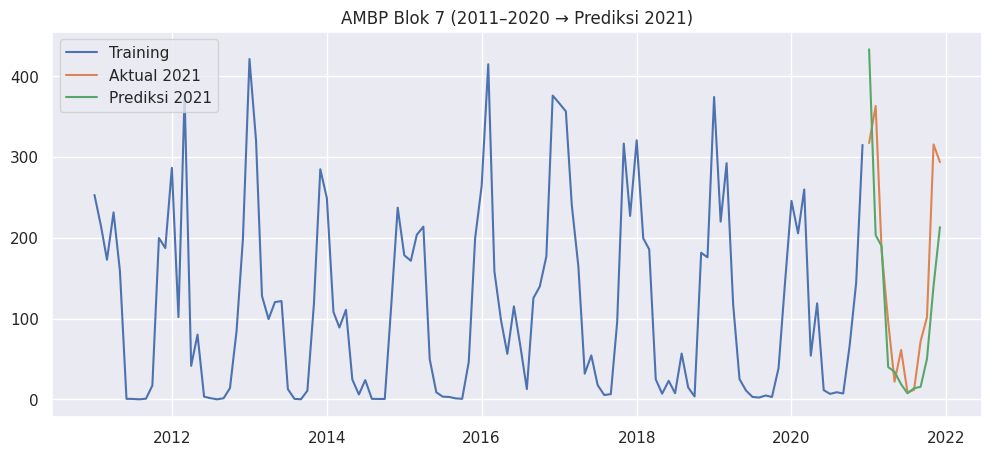

In [ ]:
# ==============================
# AMBP BLOK 7 (FULL 1 CELL)
# ==============================

# Library AMBP (Neural Network)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# DATA
# ==============================
train_block7 = rain_series['2011-01-01':'2020-12-01']
actual_2021 = rain_series['2021-01-01':'2021-12-01']

# LOG TRANSFORM
train_block7_log = np.log1p(train_block7)

print("Training size:", train_block7.shape)
print("Actual 2021 size:", actual_2021.shape)

# ==============================
# NORMALISASI
# ==============================
scaler_block7 = MinMaxScaler()

train_scaled_block7 = scaler_block7.fit_transform(
    train_block7_log.values.reshape(-1,1)
)

# ==============================
# FUNGSI LAG
# ==============================
def create_lagged_data(data, lag):
    X, y = [], []
    for i in range(lag, len(data)):
        X.append(data[i-lag:i].flatten())
        y.append(data[i])
    return np.array(X), np.array(y)

lag = 12

X_train_b7, y_train_b7 = create_lagged_data(train_scaled_block7, lag)

print("X shape:", X_train_b7.shape)
print("y shape:", y_train_b7.shape)

# ==============================
# MODEL AMBP
# ==============================
model_b7 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b7.fit(X_train_b7, y_train_b7.ravel())

print("\nTraining selesai")
print("Iterations:", model_b7.n_iter_)

# ===============================
# ERROR TRAINING
# ===============================
train_pred_scaled = model_b7.predict(X_train_b7)

train_pred = scaler_block7.inverse_transform(
    train_pred_scaled.reshape(-1,1)
)

train_actual = scaler_block7.inverse_transform(y_train_b7)

train_pred = np.expm1(train_pred)
train_actual = np.expm1(train_actual)

mae_train = mean_absolute_error(train_actual, train_pred)
mse_train = mean_squared_error(train_actual, train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train_actual, train_pred)

print("\n=== ERROR TRAINING BLOK 7 ===")
print("MAE :", mae_train)
print("MSE :", mse_train)
print("RMSE:", rmse_train)
print("R2  :", r2_train)

# ===============================
# PREDIKSI 12 BULAN
# ===============================
last_12_months = train_scaled_block7[-lag:]

forecast_scaled = []

current_input = last_12_months.copy()

for i in range(12):
    pred = model_b7.predict(current_input.reshape(1,-1))
    forecast_scaled.append(pred[0])
    current_input = np.append(current_input[1:], pred)

forecast_block7 = scaler_block7.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

forecast_block7 = np.expm1(forecast_block7)
forecast_block7 = np.maximum(forecast_block7, 0)

forecast_block7 = pd.Series(
    forecast_block7,
    index=actual_2021.index
)

print("\n=== HASIL PREDIKSI 12 BULAN (2021) ===")
print(forecast_block7)

# ===============================
# AKTUAL VS PREDIKSI
# ===============================
comparison_2021 = pd.DataFrame({
    'AKTUAL_2021': actual_2021,
    'PREDIKSI_2021': forecast_block7
})

print("\n=== PERBANDINGAN AKTUAL VS PREDIKSI ===")
print(comparison_2021)

# ===============================
# ERROR PREDIKSI
# ===============================
mae_pred = mean_absolute_error(actual_2021, forecast_block7)
mse_pred = mean_squared_error(actual_2021, forecast_block7)
rmse_pred = np.sqrt(mse_pred)
r2_pred = r2_score(actual_2021, forecast_block7)

print("\n=== ERROR PREDIKSI 2021 ===")
print("MAE :", mae_pred)
print("MSE :", mse_pred)
print("RMSE:", rmse_pred)
print("R2  :", r2_pred)

# ===============================
# SIMPAN HASIL BLOK 7
# ===============================
mae_train_b7 = mae_train
mse_train_b7 = mse_train
rmse_train_b7 = rmse_train
r2_train_b7 = r2_train

mae_pred_b7 = mae_pred
mse_pred_b7 = mse_pred
rmse_pred_b7 = rmse_pred
r2_pred_b7 = r2_pred

ambp_results.append({
    "block": 7,
    "MAE_Train": mae_train,
    "MSE_Train": mse_train,
    "RMSE_Train": rmse_train,
    "R2_Train": r2_train,
    "MAE_Pred": mae_pred,
    "MSE_Pred": mse_pred,
    "RMSE_Pred": rmse_pred,
    "R2_Pred": r2_pred
})

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block7.index, train_block7, label="Training")
plt.plot(actual_2021.index, actual_2021, label="Aktual 2021")
plt.plot(forecast_block7.index, forecast_block7, label="Prediksi 2021")

plt.title("AMBP Blok 7 (2011–2020 → Prediksi 2021)")
plt.legend()
plt.show()

# BLOK 8 - PREDIKSI 2026


Training selesai
Iterations: 439

=== PREDIKSI 2026 ===
2026-01-01    288.366456
2026-02-01    308.969006
2026-03-01    158.055044
2026-04-01     52.822521
2026-05-01     29.136434
2026-06-01     18.992374
2026-07-01     12.888240
2026-08-01     11.007929
2026-09-01     24.780105
2026-10-01     66.201490
2026-11-01    220.207599
2026-12-01    370.083911
Freq: MS, dtype: float64


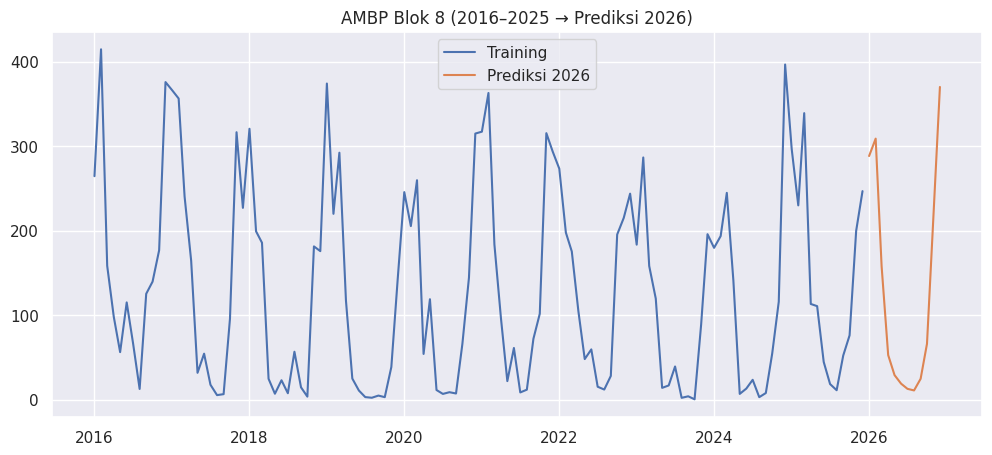

In [ ]:
# ==============================
# AMBP BLOK 8 (2016–2025 → 2026)
# ==============================

# DATA
train_block8 = rain_series['2016-01-01':'2025-12-01']

# LOG TRANSFORM
train_block8_log = np.log1p(train_block8)

# SCALING
scaler_block8 = MinMaxScaler()
train_scaled_block8 = scaler_block8.fit_transform(
    train_block8_log.values.reshape(-1,1)
)

# LAG
lag = 12
X_train_b8, y_train_b8 = create_lagged_data(train_scaled_block8, lag)

# MODEL
model_b8 = MLPRegressor(
    hidden_layer_sizes=(20,10),
    activation='relu',
    solver='adam',
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

model_b8.fit(X_train_b8, y_train_b8.ravel())

print("Training selesai")
print("Iterations:", model_b8.n_iter_)

# ===============================
# FORECAST 2026
# ===============================
last = train_scaled_block8[-lag:]

forecast_scaled = []
cur = last.copy()

for i in range(12):
    p = model_b8.predict(cur.reshape(1,-1))
    forecast_scaled.append(p[0])
    cur = np.append(cur[1:], p)

forecast_block8 = scaler_block8.inverse_transform(
    np.array(forecast_scaled).reshape(-1,1)
).flatten()

# inverse log
forecast_block8 = np.expm1(forecast_block8)

# hindari negatif
forecast_block8 = np.maximum(forecast_block8, 0)

forecast_block8 = pd.Series(
    forecast_block8,
    index=pd.date_range(start='2026-01-01', periods=12, freq='MS')
)

print("\n=== PREDIKSI 2026 ===")
print(forecast_block8)

# ===============================
# PLOT
# ===============================
plt.figure(figsize=(12,5))

plt.plot(train_block8.index, train_block8, label="Training")
plt.plot(forecast_block8.index, forecast_block8, label="Prediksi 2026")

plt.title("AMBP Blok 8 (2016–2025 → Prediksi 2026)")
plt.legend()
plt.show()

# REKAP RATA-RATA AMBP

# Jangan pakai MAPE untuk data hujan
→ karena banyak nilai kecil (bikin error jadi besar banget)

In [ ]:
# ===============================
# REKAP RATA-RATA AMBP (FINAL)
# ===============================

import numpy as np

# pastikan sudah ada
# ambp_results = []

# ===============================
# TRAINING
# ===============================
mae_train_list = [res['MAE_Train'] for res in ambp_results]
mse_train_list = [res['MSE_Train'] for res in ambp_results]
rmse_train_list = [res['RMSE_Train'] for res in ambp_results]
r2_train_list = [res['R2_Train'] for res in ambp_results]

# ===============================
# PREDIKSI
# ===============================
mae_pred_list = [res['MAE_Pred'] for res in ambp_results]
mse_pred_list = [res['MSE_Pred'] for res in ambp_results]
rmse_pred_list = [res['RMSE_Pred'] for res in ambp_results]
r2_pred_list = [res['R2_Pred'] for res in ambp_results]

# ===============================
# PRINT
# ===============================
print("=== RATA-RATA AMBP ===")

print("\n--- TRAINING ---")
print(f"MAE  : {np.mean(mae_train_list):.4f}")
print(f"MSE  : {np.mean(mse_train_list):.4f}")
print(f"RMSE : {np.mean(rmse_train_list):.4f}")
print(f"R2   : {np.mean(r2_train_list):.4f}")

print("\n--- PREDIKSI ---")
print(f"MAE  : {np.mean(mae_pred_list):.4f}")
print(f"MSE  : {np.mean(mse_pred_list):.4f}")
print(f"RMSE : {np.mean(rmse_pred_list):.4f}")
print(f"R2   : {np.mean(r2_pred_list):.4f}")

=== RATA-RATA AMBP ===

--- TRAINING ---
MAE  : 44.8179
MSE  : 4687.8366
RMSE : 67.6001
R2   : 0.5702

--- PREDIKSI ---
MAE  : 63.8426
MSE  : 7955.2791
RMSE : 83.2116
R2   : 0.3072


# PERBANDINGAN MODEL (RATA-RATA PREDIKSI)

In [ ]:
import numpy as np
import pandas as pd

# ===============================
# FUNGSI RATA-RATA
# ===============================
def calculate_average(results):
    return {
        "MAE": np.mean([r["MAE_Pred"] for r in results]),
        "MSE": np.mean([r["MSE_Pred"] for r in results]),
        "RMSE": np.mean([r["RMSE_Pred"] for r in results]),
        "R2": np.mean([r["R2_Pred"] for r in results]),
    }

# ===============================
# HITUNG RATA-RATA
# ===============================
ambp_avg = calculate_average(ambp_results)
sarima_avg = calculate_average(sarima_results)

# ===============================
# TABEL PERBANDINGAN
# ===============================
comparison_df = pd.DataFrame({
    "AMBP": ambp_avg,
    "SARIMA": sarima_avg
})

print("=== PERBANDINGAN MODEL (RATA-RATA PREDIKSI) ===")
print(comparison_df.round(4))

# ===============================
# MENENTUKAN MODEL TERBAIK
# ===============================
print("\n=== KESIMPULAN ===")

if ambp_avg["RMSE"] < sarima_avg["RMSE"] and ambp_avg["R2"] > sarima_avg["R2"]:
    print("Model terbaik: AMBP")
elif sarima_avg["RMSE"] < ambp_avg["RMSE"] and sarima_avg["R2"] > ambp_avg["R2"]:
    print("Model terbaik: SARIMA")
else:
    print("Perlu analisis lanjut (trade-off antar metrik)")

=== PERBANDINGAN MODEL (RATA-RATA PREDIKSI) ===
           AMBP     SARIMA
MAE     63.8426    44.2149
MSE   7955.2791  3788.9957
RMSE    83.2116    58.0772
R2       0.3072     0.6895

=== KESIMPULAN ===
Model terbaik: SARIMA


Bandingkan antar model

AMBP
SARIMA

👉 pilih yang:
*   MAE lebih kecil
*   RMSE lebih kecil
*   R² lebih tinggi

Contoh simpulan:

“Model SARIMA (2,0,1)(1,1,1,12) dipilih karena memiliki error lebih rendah dan R² lebih tinggi dibanding model lainnya.”

# TABEL PERBANDINGAN PREDIKSI 2026

In [ ]:
# ===============================
# TABEL PERBANDINGAN PREDIKSI 2026
# ===============================

comparison_2026 = pd.DataFrame({
    "AMBP": forecast_block8,
    "SARIMA": forecast
})

# selisih (opsional, sangat bagus untuk analisis)
comparison_2026["Selisih"] = comparison_2026["AMBP"] - comparison_2026["SARIMA"]

print("=== PERBANDINGAN PREDIKSI 2026 ===")
print(comparison_2026.round(2))

=== PERBANDINGAN PREDIKSI 2026 ===
              AMBP  SARIMA  Selisih
2026-01-01  288.37  287.95     0.42
2026-02-01  308.97  248.37    60.60
2026-03-01  158.06  244.22   -86.17
2026-04-01   52.82  100.47   -47.65
2026-05-01   29.14   56.35   -27.22
2026-06-01   18.99   41.43   -22.44
2026-07-01   12.89   21.20    -8.31
2026-08-01   11.01   12.31    -1.31
2026-09-01   24.78   36.83   -12.05
2026-10-01   66.20   76.05    -9.85
2026-11-01  220.21  181.65    38.55
2026-12-01  370.08  263.98   106.10
